In [1]:
pip install datasets

Note: you may need to restart the kernel to use updated packages.


Tải dataset

In [2]:
from datasets import load_dataset
import json

print("1. Đang tải 50.000 mẫu từ tập CodeSearchNet (Java)...")

dataset = load_dataset("code_search_net", "java", split="train[:50000]")

records = []
for item in dataset:
    code = item.get('func_code_string', '')
    summary = item.get('func_documentation_string', '')
    
    if code and summary:
        code = code.strip()
        summary = summary.strip()
        # Lấy câu đầu tiên của Javadoc
        summary_first_sentence = summary.split('.')[0] + '.'
        
        # Lọc bỏ các đoạn code hoặc summary quá ngắn
        if len(code) > 10 and len(summary_first_sentence) > 5:
            records.append({
                "code": code,
                "summary": summary_first_sentence
            })

print(f"-> Đã trích xuất thành công {len(records)} mẫu dữ liệu RAW!")

1. Đang tải 50.000 mẫu từ tập CodeSearchNet (Java)...


-> Đã trích xuất thành công 49783 mẫu dữ liệu RAW!


In [3]:
# Đổi tên file lưu trữ thành _50k để dễ phân biệt với bản full
output_file = "codesearchnet_java_50k.json"
with open(output_file, "w", encoding="utf-8") as f:
    json.dump(records, f, ensure_ascii=False, indent=4)

print(f"-> Hoàn tất! Dữ liệu đã được lưu tại: {output_file}")
with open("codesearchnet_java_50k.json", "w", encoding="utf-8") as f:
    json.dump(records, f, ensure_ascii=False, indent=2)

-> Hoàn tất! Dữ liệu đã được lưu tại: codesearchnet_java_50k.json


Trực quan hóa dữ liệu

Đang đọc dữ liệu...

Code (tokens):
  Mean   : 109.96
  Median : 64.00
  P95    : 316.00
  Max    : 10596

Summary (words):
  Mean   : 10.82
  Median : 9.00
  P95    : 25.00
  Max    : 206


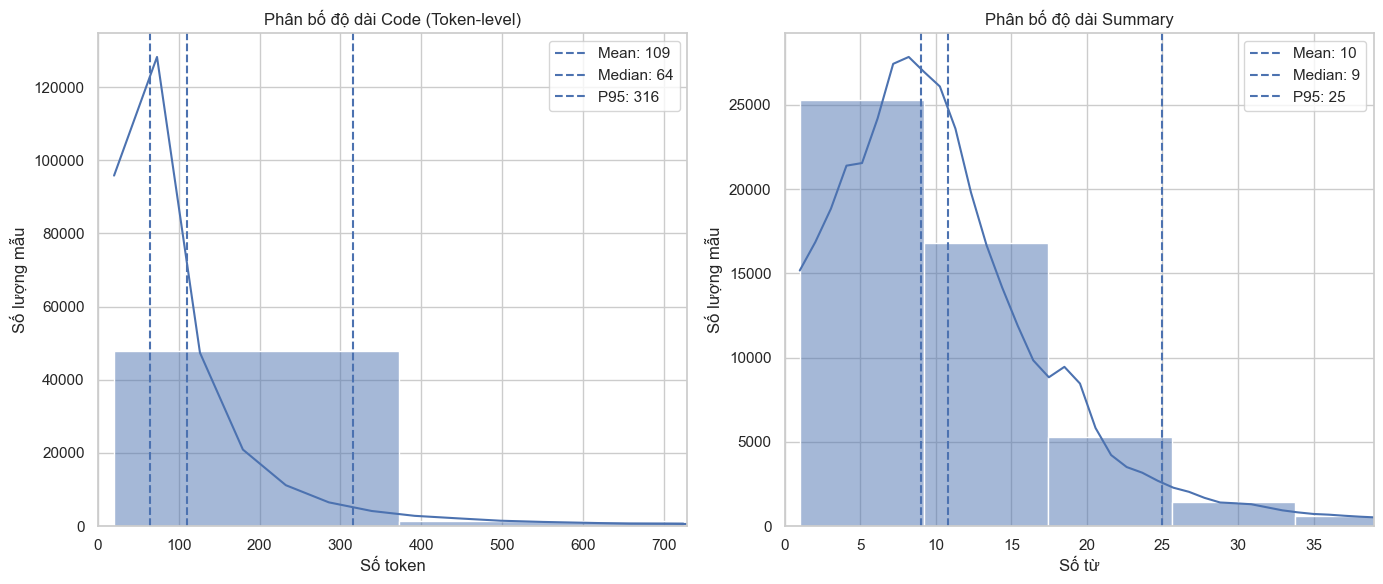

In [2]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import javalang

print("Đang đọc dữ liệu...")

with open("codesearchnet_java_50k.json", "r", encoding="utf-8") as f:
    dataset = json.load(f)

# 1. Tokenize code (đúng chuẩn hơn split)
def count_code_tokens(code):
    try:
        tokens = list(javalang.tokenizer.tokenize(code))
        return len(tokens)
    except:
        return 0

# 2. Tính độ dài
code_lengths = []
summary_lengths = []

for item in dataset:
    code = item.get("code", "")
    summary = item.get("summary", "")

    code_len = count_code_tokens(code)
    if code_len > 0:
        code_lengths.append(code_len)

    summary_lengths.append(len(summary.split()))

code_lengths = np.array(code_lengths)
summary_lengths = np.array(summary_lengths)

# 3. Thống kê
def stats(name, data):
    print(f"\n{name}:")
    print(f"  Mean   : {np.mean(data):.2f}")
    print(f"  Median : {np.median(data):.2f}")
    print(f"  P95    : {np.percentile(data, 95):.2f}")
    print(f"  Max    : {np.max(data)}")

stats("Code (tokens)", code_lengths)
stats("Summary (words)", summary_lengths)

# 4. Vẽ biểu đồ

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- CODE ----
sns.histplot(code_lengths, bins=30, kde=True, ax=axes[0])
axes[0].set_xlim(0, np.percentile(code_lengths, 99))

mean_c = np.mean(code_lengths)
median_c = np.median(code_lengths)
p95_c = np.percentile(code_lengths, 95)

axes[0].axvline(mean_c, linestyle='--', label=f"Mean: {int(mean_c)}")
axes[0].axvline(median_c, linestyle='--', label=f"Median: {int(median_c)}")
axes[0].axvline(p95_c, linestyle='--', label=f"P95: {int(p95_c)}")

axes[0].set_title("Phân bố độ dài Code (Token-level)")
axes[0].set_xlabel("Số token")
axes[0].set_ylabel("Số lượng mẫu")
axes[0].legend()

# ---- SUMMARY ----
sns.histplot(summary_lengths, bins=25, kde=True, ax=axes[1])
axes[1].set_xlim(0, np.percentile(summary_lengths, 99))

mean_s = np.mean(summary_lengths)
median_s = np.median(summary_lengths)
p95_s = np.percentile(summary_lengths, 95)

axes[1].axvline(mean_s, linestyle='--', label=f"Mean: {int(mean_s)}")
axes[1].axvline(median_s, linestyle='--', label=f"Median: {int(median_s)}")
axes[1].axvline(p95_s, linestyle='--', label=f"P95: {int(p95_s)}")

axes[1].set_title("Phân bố độ dài Summary")
axes[1].set_xlabel("Số từ")
axes[1].set_ylabel("Số lượng mẫu")
axes[1].legend()

plt.tight_layout()
plt.show()

Parse code → AST

In [9]:
import javalang

# =========================
# NODE TYPE MAP
# =========================
NODE_TYPE_MAP = {
    "MethodDeclaration": 0,
    "FormalParameter": 1,
    "ReferenceType": 2,
    "BasicType": 3,
    "LocalVariableDeclaration": 4,
    "VariableDeclarator": 5,
    "MemberReference": 6,
    "IfStatement": 7,
    "BinaryOperation": 8,
    "ReturnStatement": 9,
    "Literal": 10,
    "Token": 50,
    "Unknown": 99
}

In [10]:
# =========================
# PARSE CODE → AST
# =========================
def robust_parse(code_snippet):
    # Case 1: Method hoàn chỉnh
    try:
        tree = javalang.parse.parse(f"class Dummy {{ {code_snippet} }}")
        for t in tree.types:
            for m in t.body:
                if isinstance(m, javalang.tree.MethodDeclaration):
                    return m
    except:
        pass

    # Case 2: Code snippet (không phải method)
    try:
        tree = javalang.parse.parse(
            f"class Dummy {{ void dummy() {{ {code_snippet} }} }}"
        )
        return tree.types[0].body[0].body[0]
    except:
        return None


<i>Test with sample_code</i>

In [11]:
# =========================
# TEST PARSE
# =========================
sample_code = """
public int add(int a, int b) {
    int c = a + b;
    return c;
}
"""

ast_root = robust_parse(sample_code)

if ast_root:
    print("Parse AST thành công!")
    print("Root node:", type(ast_root).__name__)
else:
    print("Parse thất bại!")

Parse AST thành công!
Root node: MethodDeclaration


Parse + filter dataset (save clean data)

In [14]:
import json
import os

INPUT_FILE = "codesearchnet_java_50k.json"
OUTPUT_FILE = "clean_dataset.json"

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    dataset = json.load(f)

clean_data = []
fail = 0

for idx, item in enumerate(dataset):
    code = item.get("code", "")
    summary = item.get("summary", "")

    ast_root = robust_parse(code)

    if ast_root is not None:
        clean_data.append({
            "code": code,
            "summary": summary
        })
    else:
        fail += 1

    if idx % 1000 == 0:
        print(f"Processed {idx} samples...")

# Lưu lại dataset sạch
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(clean_data, f)

print("Done parse!")
print("Valid samples:", len(clean_data))
print("Failed samples:", fail)

Processed 0 samples...
Processed 1000 samples...
Processed 2000 samples...
Processed 3000 samples...
Processed 4000 samples...
Processed 5000 samples...
Processed 6000 samples...
Processed 7000 samples...
Processed 8000 samples...
Processed 9000 samples...
Processed 10000 samples...
Processed 11000 samples...
Processed 12000 samples...
Processed 13000 samples...
Processed 14000 samples...
Processed 15000 samples...
Processed 16000 samples...
Processed 17000 samples...
Processed 18000 samples...
Processed 19000 samples...
Processed 20000 samples...
Processed 21000 samples...
Processed 22000 samples...
Processed 23000 samples...
Processed 24000 samples...
Processed 25000 samples...
Processed 26000 samples...
Processed 27000 samples...
Processed 28000 samples...
Processed 29000 samples...
Processed 30000 samples...
Processed 31000 samples...
Processed 32000 samples...
Processed 33000 samples...
Processed 34000 samples...
Processed 35000 samples...
Processed 36000 samples...
Processed 3700

AST → Graph (PyTorch Geometric)

In [15]:
import torch
from torch_geometric.data import Data
from collections import deque
import javalang

# =========================
# BUILD GRAPH
# =========================
def ast_to_graph(ast_root, code):
    if ast_root is None:
        return None

    node_features = []
    edges = []

    queue = deque()
    queue.append((ast_root, -1, 0))
    node_id = 0

    # ===== AST GRAPH =====
    while queue:
        current_node, parent_id, depth = queue.popleft()

        node_type = type(current_node).__name__
        type_id = NODE_TYPE_MAP.get(node_type, NODE_TYPE_MAP["Unknown"])

        node_features.append([type_id, depth])
        current_id = node_id
        node_id += 1

        if parent_id != -1:
            edges.append([parent_id, current_id])
            edges.append([current_id, parent_id])

        children = []
        if isinstance(current_node, javalang.tree.Node):
            for child in current_node.children:
                if isinstance(child, javalang.tree.Node):
                    children.append(child)
                elif isinstance(child, list):
                    for item in child:
                        if isinstance(item, javalang.tree.Node):
                            children.append(item)

        for c in children:
            queue.append((c, current_id, depth + 1))

    # ===== TOKEN GRAPH =====
    try:
        tokens = list(javalang.tokenizer.tokenize(code))
    except:
        tokens = []

    token_ids = []
    token_offset = len(node_features)

    for i, tok in enumerate(tokens):
        node_features.append([NODE_TYPE_MAP["Token"], 0])
        token_ids.append(token_offset + i)

    # ===== NextToken =====
    for i in range(len(token_ids) - 1):
        edges.append([token_ids[i], token_ids[i+1]])
        edges.append([token_ids[i+1], token_ids[i]])

    # ===== LastWrite =====
    last_write = {}

    for i, tok in enumerate(tokens):
        if isinstance(tok, javalang.tokenizer.Identifier):
            name = tok.value

            if name in last_write:
                edges.append([last_write[name], token_ids[i]])
                edges.append([token_ids[i], last_write[name]])

            last_write[name] = token_ids[i]

    # ===== BUILD GRAPH =====
    x = torch.tensor(node_features, dtype=torch.float)

    edges = list(set(tuple(e) for e in edges))  # remove duplicate

    if edges:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)

    return Data(x=x, edge_index=edge_index)

<i>Test Graph</i>

In [16]:
# =========================
# TEST GRAPH
# =========================
graph = ast_to_graph(ast_root, sample_code)

if graph:
    print("Tạo graph thành công!")
    print(graph)
    print("Nodes:", graph.num_nodes)
    print("Edges:", graph.num_edges)
else:
    print("Tạo graph thất bại!")

Tạo graph thành công!
Data(x=[37, 2], edge_index=[2, 76])
Nodes: 37
Edges: 76


Build Graph and Save .pt file

In [ ]:
import json
import torch
import os

# ===== LOAD DATA =====
INPUT_FILE = "clean_dataset.json"
SAVE_DIR = "graph_batches"
BATCH_SIZE = 1000

os.makedirs(SAVE_DIR, exist_ok=True)

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    dataset = json.load(f)

batch_graphs = []
batch_id = 0

for idx, item in enumerate(dataset):
    code = item["code"]
    summary = item["summary"]

    ast_root = robust_parse(code)
    graph = ast_to_graph(ast_root, code)

    if graph is not None:
        # SAVE RAW TEXT
        graph.summary = summary

        batch_graphs.append(graph)

    if len(batch_graphs) >= BATCH_SIZE:
        torch.save(batch_graphs, f"{SAVE_DIR}/batch_{batch_id}.pt")
        print(f"Saved batch {batch_id}")
        batch_graphs = []
        batch_id += 1

# save remaining
if batch_graphs:
    torch.save(batch_graphs, f"{SAVE_DIR}/batch_{batch_id}.pt")
    print(f"Saved batch {batch_id}")

Saved batch 0
Saved batch 1
Saved batch 2
Saved batch 3
Saved batch 4
Saved batch 5
Saved batch 6
Saved batch 7
Saved batch 8
Saved batch 9
Saved batch 10
Saved batch 11
Saved batch 12
Saved batch 13
Saved batch 14
Saved batch 15
Saved batch 16
Saved batch 17
Saved batch 18
Saved batch 19
Saved batch 20
Saved batch 21
Saved batch 22
Saved batch 23
Saved batch 24
Saved batch 25
Saved batch 26
Saved batch 27
Saved batch 28
Saved batch 29
Saved batch 30
Saved batch 31
Saved batch 32
Saved batch 33
Saved batch 34
Saved batch 35
Saved batch 36
Saved batch 37
Saved batch 38
Saved batch 39
Saved batch 40
Saved batch 41
Saved batch 42
Saved batch 43
Saved batch 44
Saved batch 45
